# Results: CLIP ViT-L/14 → CLIP ViT-B/32

Reproduces Table 1 (same-family upgrade, CLIP ViT-L/14 → CLIP ViT-B/32) from the CSV written by `main.py`.

- **Old model**: old-model queries against the old-model gallery (M<sub>old→old</sub>).
- **SVD**: Procrustes-aligned new-model queries (α = 1) against the old-model gallery.
- **+SLERP (α̂)**: SLERP with the weight selected on CC3M (separately for I2T and T2I).
- **+SLERP (α★)**: per-dataset oracle weight (upper bound).
- **Sup.**: support modality used to fit Procrustes (T = text, I = image, I+T = both).

✓ / × mark whether backward compatibility holds (M<sub>new→old</sub> > M<sub>old→old</sub>).

Run `python main.py --new_model l14 --old_model b32` first.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd

from slerp_bc.table import SUPPORTS, build_table, mark_compatibility, selected_alphas

CSV = "../results/l14_to_b32.csv"
SUPPORT_SET = "cc3m"
DATASETS = ["flickr30k", "coco", "nocaps"]
NAMES = {"cc3m": "CC3M val (support)", "flickr30k": "Flickr30k", "coco": "COCO", "nocaps": "NoCaps"}

df = pd.read_csv(CSV, keep_default_na=False, na_values=[""])
df.head()

,dataset,method,support,alpha,i2t_r1,i2t_r5,i2t_r10,t2i_r1,t2i_r5,t2i_r10
0,cc3m,old,-,NaN,33.275303,56.152564,64.746380,32.112050,55.036795,63.598955
1,cc3m,new,-,NaN,40.389332,62.704754,70.491415,39.495131,61.035055,68.758404
2,flickr30k,old,-,NaN,40.617141,64.751405,73.721546,21.733411,41.564456,51.104665
3,flickr30k,new,-,NaN,48.726383,72.928357,81.214941,28.275618,49.629202,59.087509
4,coco,old,-,NaN,28.765774,50.329542,59.852415,14.469951,30.223370,38.916034


## Interpolation weight α̂ selected on CC3M (Recall@1)

In [2]:
selected_alphas(df, SUPPORT_SET)

,I2T,T2I
Sup.,,
T,0.7,0.5
I,0.7,0.4
I+T,0.7,0.4


## Table 1: Recall@1 (%)

In [3]:
table = build_table(df, SUPPORT_SET, DATASETS, k=1)
mark_compatibility(table).rename(columns=NAMES, level=0)

Flickr30k              COCO            NoCaps         
                       I2T      T2I      I2T      T2I      I2T      T2I
Method      Sup.                                                       
Old model   -        40.62    21.73    28.77    14.47    71.31    45.24
SVD         T      42.89 ✓  21.49 ×  30.28 ✓  14.03 ×  69.22 ×  43.92 ×
+SLERP (α̂) T      48.00 ✓  23.33 ✓  33.41 ✓  15.26 ✓  74.00 ✓  46.59 ✓
+SLERP (α★) T      48.61 ✓  23.33 ✓  33.85 ✓  15.27 ✓  75.64 ✓  46.65 ✓
SVD         I      41.18 ✓  19.99 ×  28.71 ×  13.11 ×  65.91 ×  42.16 ×
+SLERP (α̂) I      46.30 ✓  23.00 ✓  31.77 ✓  15.14 ✓  71.44 ✓  46.49 ✓
+SLERP (α★) I      47.39 ✓  23.00 ✓  32.51 ✓  15.15 ✓  73.80 ✓  46.51 ✓
SVD         I+T    42.44 ✓  21.80 ✓  29.95 ✓  14.16 ×  69.16 ×  44.41 ×
+SLERP (α̂) I+T    47.09 ✓  23.44 ✓  33.04 ✓  15.30 ✓  73.58 ✓  46.98 ✓
+SLERP (α★) I+T    47.77 ✓  23.44 ✓  33.31 ✓  15.35 ✓  74.80 ✓  46.98 ✓
New model   -        48.73    28.28    34.33    18.69    73.36    47.84

## Recall@1 along the geodesic

α = 0 is the old model, α = 1 is the Procrustes-aligned new model (SVD). The dashed line is the old model
(the backward-compatibility threshold), the dotted line the new model; hollow markers show α̂ selected on CC3M.

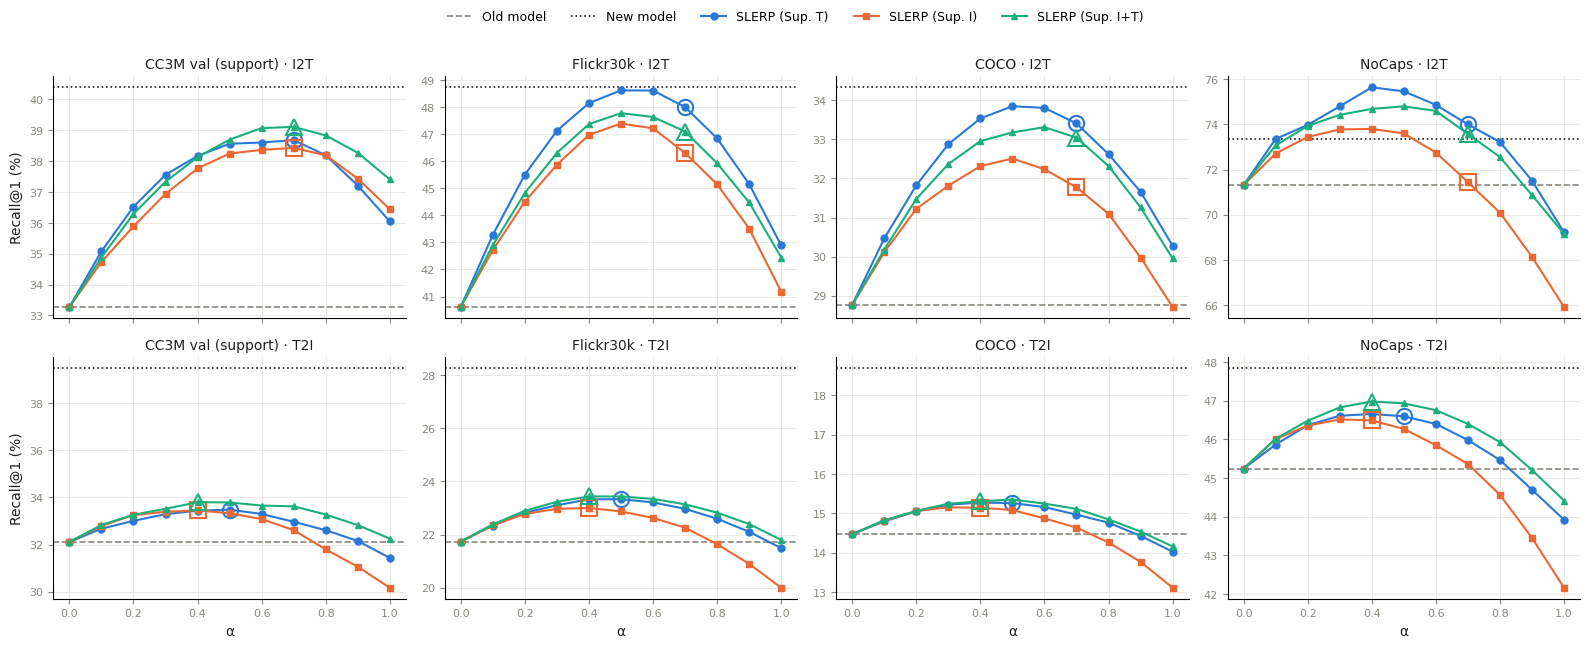

In [4]:
COLORS = {"T": "#2a78d6", "I": "#eb6834", "I+T": "#1baf7a"}
MARKERS = {"T": "o", "I": "s", "I+T": "^"}
INK, MUTED = "#1f1f1e", "#8a897f"

alphas_hat = selected_alphas(df, SUPPORT_SET)
datasets = [SUPPORT_SET] + DATASETS
fig, axes = plt.subplots(2, len(datasets), figsize=(4 * len(datasets), 6.5), sharex=True)
for row, direction in enumerate(["i2t", "t2i"]):
    metric = f"{direction}_r1"
    for col, ds in enumerate(datasets):
        ax = axes[row, col]
        rows = df[df.dataset == ds]
        old = rows[rows.method == "old"][metric].item()
        new = rows[rows.method == "new"][metric].item()
        ax.axhline(old, color=MUTED, lw=1.2, ls="--", label="Old model")
        ax.axhline(new, color=INK, lw=1.2, ls=":", label="New model")
        for sup in SUPPORTS:
            curve = rows[(rows.method == "slerp") & (rows.support == sup)].sort_values("alpha")
            if curve.empty:
                continue
            ax.plot(curve.alpha, curve[metric], color=COLORS[sup], marker=MARKERS[sup], ms=5, lw=1.5,
                    label=f"SLERP (Sup. {sup})")
            a_hat = alphas_hat.loc[sup, direction.upper()]
            ax.plot(a_hat, curve[curve.alpha.round(6) == round(a_hat, 6)][metric].item(), marker=MARKERS[sup],
                    ms=11, mfc="none", mec=COLORS[sup], mew=1.5, ls="none")
        ax.set_title(f"{NAMES[ds]} · {direction.upper()}", fontsize=10, color=INK)
        ax.grid(color="#e6e5df", lw=0.6)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(colors=MUTED, labelsize=8)
        if col == 0:
            ax.set_ylabel("Recall@1 (%)", color=INK)
        if row == 1:
            ax.set_xlabel("α", color=INK)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(labels), frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()